In [1]:
import scipy.stats as stats
import numpy as np
import sys
sys.path.append('../')
from src.data_generator import generator_fintech_data
from tqdm import tqdm

In [2]:
df = generator_fintech_data(n_users=100000, effect_size=15)


control_revenue = df[df['group'] == 'Control']['exp_revenue']
treatment_revenue = df[df['group'] == 'Treatment']['exp_revenue']
print(treatment_revenue.shape)
print(control_revenue.shape)
df.head()

(50201,)
(49799,)


,user_id,group,pre_exp_revenue,exp_revenue
0,1,Control,732.20,400.58
1,2,Treatment,341.75,980.97
2,3,Control,877.63,2234.83
3,4,Treatment,2508.99,1918.29
4,5,Control,304.61,0.00


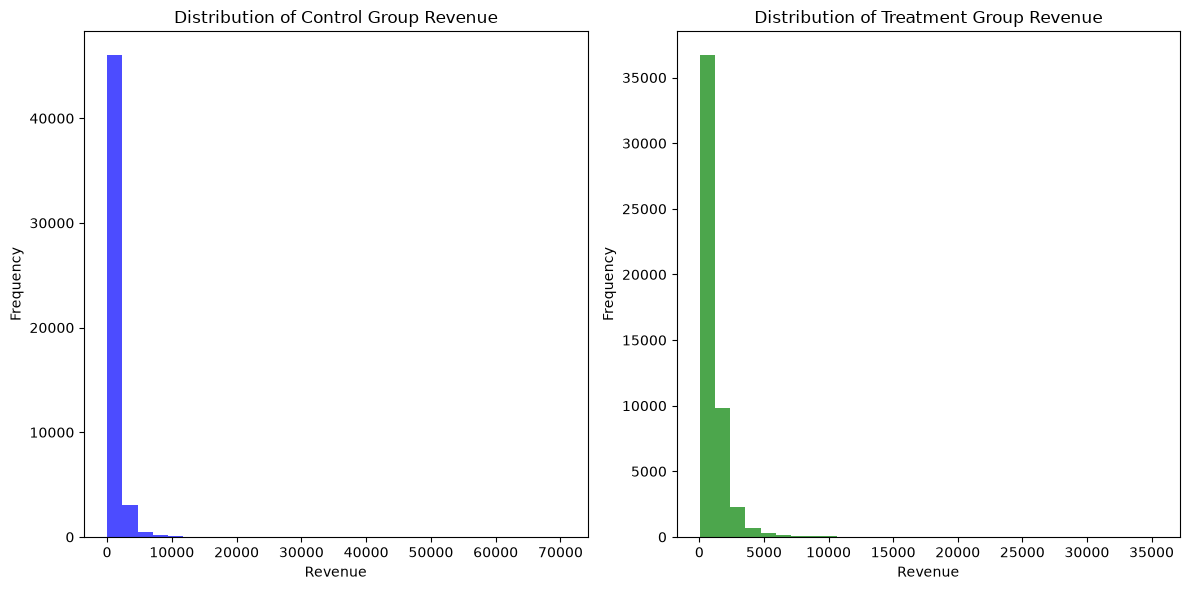

In [3]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(control_revenue, bins=30, color='blue', alpha=0.7)
plt.title('Distribution of Control Group Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(treatment_revenue, bins=30, color='green', alpha=0.7)
plt.title('Distribution of Treatment Group Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('../graphs/revenue_distributions.png')
plt.show()

In [4]:
mean_diff = treatment_revenue.mean() - control_revenue.mean()
print(f'средняя разница в доходах между группами {mean_diff:.2f}')

средняя разница в доходах между группами 7.26


In [5]:
t_stat, p_value = stats.ttest_ind(treatment_revenue, control_revenue, equal_var=False)

print(f't-statistic: {t_stat:.2f}')
print(f'p-value: {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print('Отвергаем гипотезу H0')
else:
    print('Гипотезу H0 нельзя отвергнуть')

t-statistic: 0.89
p-value: 0.3735
Гипотезу H0 нельзя отвергнуть


In [6]:
covariance = np.cov(df['exp_revenue'], df['pre_exp_revenue'])[0,1]
variance = np.var(df['pre_exp_revenue'], ddof=1)
theta = covariance / variance

mean_pre_exp = df['pre_exp_revenue'].mean()

df['cuped_revenue'] = df['exp_revenue'] - theta * (df['pre_exp_revenue'] - mean_pre_exp)

control_cuped = df[df['group'] == 'Control']['cuped_revenue']
treatment_cuped = df[df['group'] == 'Treatment']['cuped_revenue']

t_stat_cuped, p_value_cuped = stats.ttest_ind(treatment_cuped, control_cuped, equal_var=False)

if p_value_cuped < alpha:
    print('Отвергаем гипотезу H0\n')
else:
    print('Гипотезу H0 нельзя отвергнуть \n')

print(f'CUPED t-statistic: {t_stat_cuped:.2f}')
print(f'CUPED p-value: {p_value_cuped:.6f}')

Отвергаем гипотезу H0

CUPED t-statistic: 4.39
CUPED p-value: 0.000012


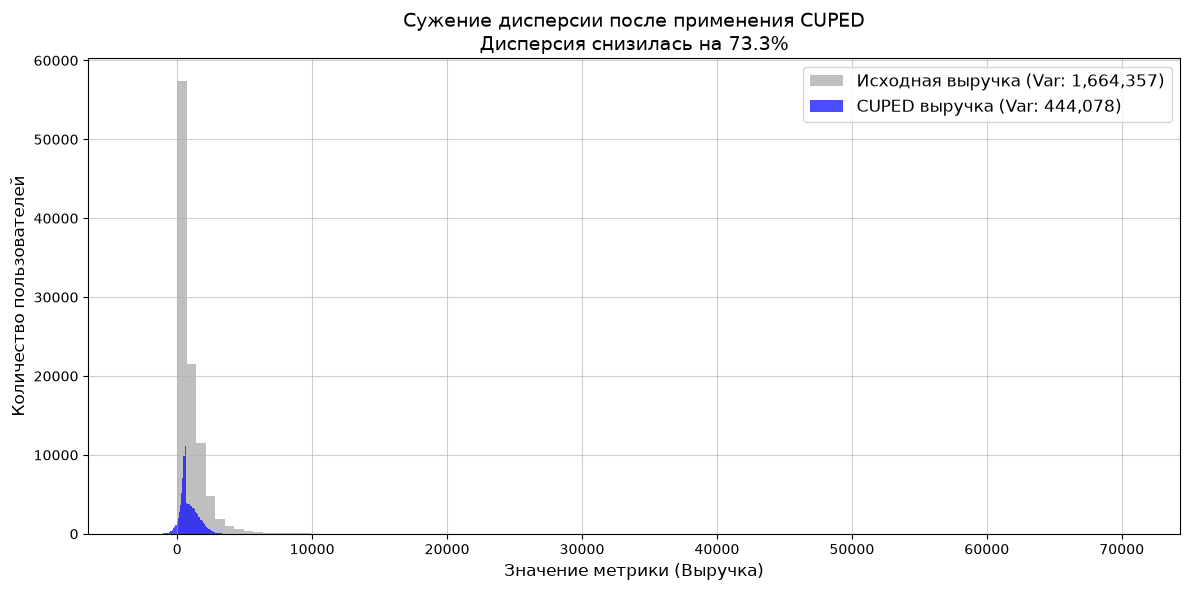

In [7]:
var_original = np.var(df['exp_revenue'], ddof=1)
var_cuped = np.var(df['cuped_revenue'], ddof=1)
variance_reduction = (1 - var_cuped / var_original) * 100

plt.figure(figsize=(12, 6))
plt.hist(df['exp_revenue'], bins=100, alpha=0.5, label=f'Исходная выручка (Var: {var_original:,.0f})', color='gray')
plt.hist(df['cuped_revenue'], bins=100, alpha=0.7, label=f'CUPED выручка (Var: {var_cuped:,.0f})', color='blue')


plt.title(f'Сужение дисперсии после применения CUPED\nДисперсия снизилась на {variance_reduction:.1f}%', fontsize=14)
plt.xlabel('Значение метрики (Выручка)', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.6)

plt.tight_layout()
plt.savefig('../graphs/cuped_variance_reduction.png')
plt.show()

In [8]:
def wilson_interval(successes, trials, confidence=0.95):
    z = stats.norm.ppf(0.5 + confidence / 2)
    p = successes / trials
    den = 1 + z*z / trials
    center = (p + z*z / (2*trials)) / den
    radius = z * np.sqrt(p*(1-p)/trials + z*z/(4*trials*trials)) / den
    return center - radius, center + radius



def monte_karlo_sim(n_trials=1000, alpha=0.05, effect_size=15,
                    n_users=100000, random_state=2026):
    trial_seeds = np.random.SeedSequence(random_state).spawn(n_trials)
    counts = np.zeros(2, dtype=int)
    reductions = []
    effects = []
    
    for trial in trial_seeds:
        seed = int(trial.generate_state(1)[0])
        frame = generator_fintech_data(n_users=n_users, effect_size=effect_size, random_state=seed)
        
        x = frame["pre_exp_revenue"].to_numpy()
        y = frame["exp_revenue"].to_numpy()
        treated = frame["group"].to_numpy() == "Treatment"
        
        theta = np.cov(y, x, ddof=1)[0, 1] / np.var(x, ddof=1)
        adjusted = y - theta * (x - x.mean())
        
        p_raw = stats.ttest_ind(y[treated], y[~treated], equal_var=False).pvalue
        p_cuped = stats.ttest_ind(adjusted[treated], adjusted[~treated], equal_var=False).pvalue
        
        counts += [p_raw < alpha, p_cuped < alpha]
        reductions.append(1 - np.var(adjusted, ddof=1) / np.var(y, ddof=1))
        effects.append([y[treated].mean()-y[~treated].mean(),
                        adjusted[treated].mean()-adjusted[~treated].mean()])
    label = "Частота ложных срабатываний" if effect_size == 0 else "Мощность"
    result = {"n_trials": n_trials, "n_users": n_users, "effect_size": effect_size,
              "alpha": alpha, "random_state": random_state}
    for method, count in zip(["Welch", "CUPED"], counts):
        low, high = wilson_interval(int(count), n_trials)
        result[method] = {"rejections": int(count), "rate": float(count/n_trials), "ci95": [float(low), float(high)]}
        print(f"{label}, {method}: {count}/{n_trials} = {count/n_trials:.1%}; "
              f"95% ДИ Монте-Карло [{low:.1%}; {high:.1%}]")
        
    result["mean_variance_reduction"] = float(np.mean(reductions))
    result["mean_estimated_effect"] = np.mean(effects, axis=0).tolist()
    
    print(f"Среднее снижение дисперсии: {np.mean(reductions):.2%}")
    print("Средняя оценка эффекта (Welch, CUPED):", result["mean_estimated_effect"])
    return result


In [9]:
print("A/A: нулевой эффект")
aa_results = monte_karlo_sim(n_trials=5000, effect_size=0, random_state=2026)
print("\nA/B: эффект +15 на пользователя")
ab_results = monte_karlo_sim(effect_size=15, random_state=2027)


A/A: нулевой эффект
Частота ложных срабатываний, Welch: 259/5000 = 5.2%; 95% ДИ Монте-Карло [4.6%; 5.8%]
Частота ложных срабатываний, CUPED: 275/5000 = 5.5%; 95% ДИ Монте-Карло [4.9%; 6.2%]
Среднее снижение дисперсии: 73.34%
Средняя оценка эффекта (Welch, CUPED): [0.1312733364091703, -0.07827792163679785]

A/B: эффект +15 на пользователя
Мощность, Welch: 432/1000 = 43.2%; 95% ДИ Монте-Карло [40.2%; 46.3%]
Мощность, CUPED: 926/1000 = 92.6%; 95% ДИ Монте-Карло [90.8%; 94.1%]
Среднее снижение дисперсии: 73.34%
Средняя оценка эффекта (Welch, CUPED): [14.79367327271645, 14.967362507355723]
